# Threshold Optimization

After training the XGBoost model, the default classification threshold of **0.50**
may not provide the best balance between precision and recall.

This notebook evaluates multiple decision thresholds to determine the most
suitable threshold for detecting fraudulent job postings.

### Objectives

- Load the trained model and TF-IDF vectorizer
- Evaluate multiple thresholds
- Compare Precision, Recall and F1-score
- Select the best threshold based on F1-score
- Recommend a threshold for recall-prioritized applications

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


# Load the Dataset

Load the cleaned dataset used during model training.

In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../processed_data/preprocessed_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (15665, 21)


,title,location,company_profile,description,requirements,telecommuting,has_company_logo,has_questions,employment_type,required_experience,...,industry,fraudulent,combined_text,employment_type_enc,required_experience_enc,required_education_enc,company_profile_missing,requirements_missing,industry_missing,location_missing
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,0,1,0,Other,Internship,...,NaN,0,marketing intern we re food52 and we ve create...,2,4,9,0,0,1,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,0,1,0,Full-time,Not Applicable,...,Marketing and Advertising,0,customer service cloud video production 90 sec...,1,6,9,0,0,0,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,0,1,0,Unknown,Unknown,...,NaN,0,commissioning machinery assistant cma valor se...,5,7,9,0,0,1,0
3,Account Executive - Washington DC,"US, DC, Washington",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",0,1,0,Full-time,Mid-Senior level,...,Computer Software,0,account executive washington dc our passion fo...,1,5,1,0,0,0,0
4,Bill Review Manager,"US, FL, Fort Worth",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,0,1,1,Full-time,Mid-Senior level,...,Hospital & Health Care,0,bill review manager spotsource solutions llc i...,1,5,1,0,0,0,0


# Split Dataset

The same train-test split is recreated using the same random state to ensure
the threshold analysis is performed on the identical test set.

In [3]:
# ==========================================
# Train-Test Split
# ==========================================

X = df["combined_text"]
y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 12532
Testing Samples : 3133


# Load Saved Model

Load the trained TF-IDF vectorizer and XGBoost model.

In [4]:
# ==========================================
# Load Model Artifacts
# ==========================================

tfidf = joblib.load("../models/tfidf_vectorizer.joblib")
model = joblib.load("../models/xgb_model.joblib")

print("Model Loaded Successfully.")

Model Loaded Successfully.


# Convert Test Data into TF-IDF Features

In [5]:
# ==========================================
# Transform Test Data
# ==========================================

X_test_vec = tfidf.transform(X_test)

probs = model.predict_proba(X_test_vec)[:,1]

print("Probability predictions generated.")

Probability predictions generated.


# Evaluate Different Thresholds

The classifier is evaluated across thresholds ranging from **0.10 to 0.90**.

For each threshold, the following metrics are calculated:

- Precision
- Recall
- F1-score

In [6]:
# ==========================================
# Threshold Sweep
# ==========================================

results = []

print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1 Score':>10}")

print("-"*52)

for threshold in np.arange(0.10,0.95,0.05):

    predictions = (probs >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

    print(f"{threshold:>10.2f} | {precision:>10.3f} | {recall:>10.3f} | {f1:>10.3f}")

 Threshold |  Precision |     Recall |   F1 Score
----------------------------------------------------
      0.10 |      0.585 |      0.830 |      0.686
      0.15 |      0.646 |      0.801 |      0.715
      0.20 |      0.689 |      0.787 |      0.735
      0.25 |      0.745 |      0.745 |      0.745
      0.30 |      0.780 |      0.730 |      0.755
      0.35 |      0.803 |      0.723 |      0.761
      0.40 |      0.820 |      0.709 |      0.760
      0.45 |      0.841 |      0.674 |      0.748
      0.50 |      0.833 |      0.638 |      0.723
      0.55 |      0.857 |      0.638 |      0.732
      0.60 |      0.869 |      0.610 |      0.717
      0.65 |      0.884 |      0.596 |      0.712
      0.70 |      0.901 |      0.582 |      0.707
      0.75 |      0.907 |      0.553 |      0.687
      0.80 |      0.926 |      0.532 |      0.676
      0.85 |      0.934 |      0.504 |      0.654
      0.90 |      0.944 |      0.482 |      0.638


In [7]:
# ==========================================
# Convert Results to DataFrame
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.585000,0.829787,0.686217
1,0.15,0.645714,0.801418,0.715190
2,0.20,0.689441,0.787234,0.735099
3,0.25,0.744681,0.744681,0.744681
4,0.30,0.780303,0.730496,0.754579
5,0.35,0.803150,0.723404,0.761194
6,0.40,0.819672,0.709220,0.760456
7,0.45,0.840708,0.673759,0.748031
8,0.50,0.833333,0.638298,0.722892
9,0.55,0.857143,0.638298,0.731707


# Best Threshold based on F1 Score

In [8]:
# ==========================================
# Best Threshold
# ==========================================

best = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Threshold Based on F1 Score\n")

print(best)

Best Threshold Based on F1 Score

Threshold    0.350000
Precision    0.803150
Recall       0.723404
F1 Score     0.761194
Name: 5, dtype: float64


# Recall Prioritized Threshold

Sometimes detecting more fraudulent jobs is more important than maximizing
overall accuracy.

This section finds the threshold that maintains at least **80% recall**
while maximizing precision.

In [9]:
# ==========================================
# Recall Priority Threshold
# ==========================================

recall_priority = results_df[
    results_df["Recall"] >= 0.80
]

if not recall_priority.empty:

    best_option = recall_priority.sort_values(
        by="Precision",
        ascending=False
    ).iloc[0]

    print("Best Recall Priority Threshold\n")

    print(best_option)

else:

    print("No threshold achieved Recall ≥ 0.80")

Best Recall Priority Threshold

Threshold    0.150000
Precision    0.645714
Recall       0.801418
F1 Score     0.715190
Name: 1, dtype: float64


# Threshold Performance Visualization

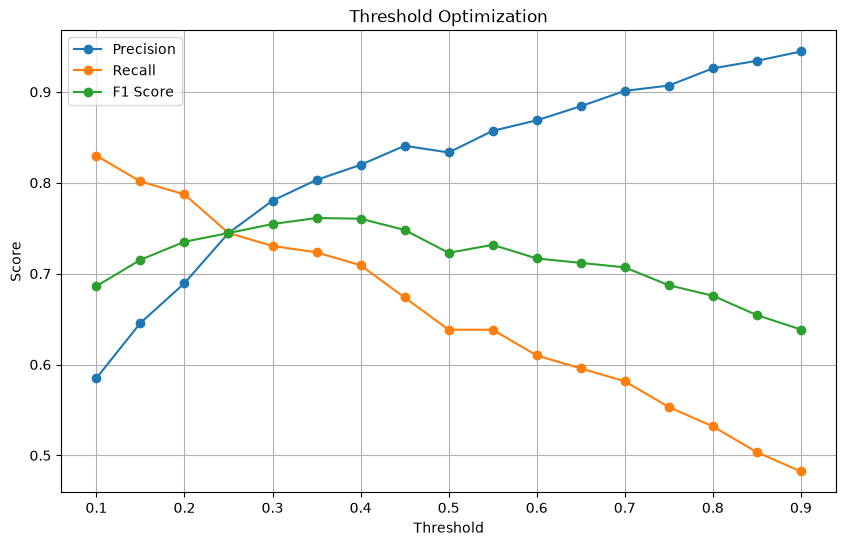

In [10]:
# ==========================================
# Plot Threshold Metrics
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    results_df["Threshold"],
    results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.grid(True)

plt.legend()

plt.show()

# Conclusion

The threshold sweep demonstrates how classification performance changes with
different probability cutoffs.

Instead of using the default threshold of **0.50**, the threshold that
maximizes the **F1-score** can be selected for balanced performance.

For applications where detecting fraudulent job postings is the highest
priority, a recall-oriented threshold can also be chosen.